In [1]:
%pwd

'/Users/harshpatel/Desktop/Projects/customer-churn-prediction/notebooks'

In [2]:
import pandas as pd
df = pd.read_csv('data/processed_data.csv')

In [3]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In churn prediction, recall (and metrics derived from it, like F1) is usually the most important — here’s why:

1️⃣ Business context
Churn prediction is asymmetric in cost:

- False Negative (FN): You predict a customer will not churn, but they actually leave → you miss the chance to intervene and keep them.

- False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

- Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

Typical priority
- If retention campaigns are cheap → prioritize recall (catch every possible churner).
- If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import pandas as pd
import time

In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

## Experiment Tracking using MLflow

In [ ]:
import mlflow

mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
mlflow.set_experiment("Telco Churn - Baseline Models")

## Threshold 

The prediction threshold was reduced from **0.5 to 0.25** to identify more churn customers. This increased the model's Recall and helped reduce the number of missed churn cases, which is important for customer retention.


In [7]:
THRESHOLD = 0.25  # lower than 0.5 to boost recall (see next to choose the right value)

### RandomForest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time

rf_params = {
    "n_estimators": 300,
    "class_weight": "balanced",   # handles imbalance for you
    "random_state": 42,
    "n_jobs": -1
}

with mlflow.start_run(run_name="RandomForest"):
    mlflow.log_params(rf_params)
    mlflow.log_param("threshold", THRESHOLD)

    # Training timer
    start_train = time.time()
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction timer
    start_pred = time.time()
    proba = rf.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.sklearn.log_model(rf, "model")

    print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.898     0.694     0.783      1033
           1      0.481     0.783     0.596       374

    accuracy                          0.718      1407
   macro avg      0.690     0.739     0.690      1407
weighted avg      0.788     0.718     0.733      1407



→ You’re now catching 71.7% of actual churners with RandomForest

### LightGBM classifier

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time

lgbm_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

with mlflow.start_run(run_name="LightGBM"):
    mlflow.log_params(lgbm_params)
    mlflow.log_param("threshold", THRESHOLD)

    # Training timer
    start_train = time.time()
    lgbm = LGBMClassifier(**lgbm_params)
    lgbm.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)
    print(f"⏱ Training time: {train_time:.2f} seconds")

    # Prediction timer
    start_pred = time.time()
    proba = lgbm.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)
    print(f"⏱ Prediction time: {pred_time:.4f} seconds")

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.lightgbm.log_model(lgbm, "model")

    # Classification report
    print(classification_report(y_test, y_pred, digits=3))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 2.56 seconds
⏱ Prediction time: 0.0118 seconds
              precision    recall  f1-score   support

           0      0.920     0.656     0.766      1033
           1      0.470     0.842     0.603       374

    accuracy                          0.706      1407
   macro avg      0.695     0.749     0.685      1407
weighted avg      0.800     0.70

→ You’re now catching 82% of actual churners with LightGBM (improvement)
- The cost is a small drop in precision — meaning more loyal customers will be flagged as churn risks — but if retention offers are low-cost, this is fine.

### XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
}

with mlflow.start_run(run_name="XGBoost"):
    mlflow.log_params(xgb_params)
    mlflow.log_param("threshold", THRESHOLD)

    # Training timer
    start_train = time.time()
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)
    print(f"⏱ Training time: {train_time:.2f} seconds")

    # Prediction timer
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)
    print(f"⏱ Prediction time: {pred_time:.4f} seconds")

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # Save model
    mlflow.xgboost.log_model(xgb, "model")

    # Classification report
    print(classification_report(y_test, y_pred, digits=3))


⏱ Training time: 0.79 seconds
⏱ Prediction time: 0.0043 seconds
              precision    recall  f1-score   support

           0      0.912     0.639     0.751      1033
           1      0.454     0.829     0.587       374

    accuracy                          0.689      1407
   macro avg      0.683     0.734     0.669      1407
weighted avg      0.790     0.689     0.707      1407



### ML model choise XGBoost
- Gives a decent recall (same as LightGBM)
- AND faster to train (3x faster)

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [11]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-06-20 13:22:55,124] A new study created in memory with name: no-name-3763f25f-edb1-4188-b538-7b9dc261def7
[I 2026-06-20 13:22:56,010] Trial 0 finished with value: 0.8449197860962567 and parameters: {'n_estimators': 638, 'learning_rate': 0.09776440579426882, 'max_depth': 7, 'subsample': 0.7150152430845276, 'colsample_bytree': 0.9868447445291453, 'min_child_weight': 5, 'gamma': 1.1894257310618, 'reg_alpha': 1.2877274517815813, 'reg_lambda': 0.2595484733068154}. Best is trial 0 with value: 0.8449197860962567.
[I 2026-06-20 13:22:56,455] Trial 1 finished with value: 0.9064171122994652 and parameters: {'n_estimators': 471, 'learning_rate': 0.04057443847006488, 'max_depth': 9, 'subsample': 0.9681317481389515, 'colsample_bytree': 0.6927245039712854, 'min_child_weight': 7, 'gamma': 2.3599642434677426, 'reg_alpha': 0.4415654881521458, 'reg_lambda': 4.333602493694265}. Best is trial 1 with value: 0.9064171122994652.
[I 2026-06-20 13:22:56,892] Trial 2 finished with value: 0.9331550802139

Best Params: {'n_estimators': 325, 'learning_rate': 0.01571966571767141, 'max_depth': 6, 'subsample': 0.9999844658800113, 'colsample_bytree': 0.8014927975423601, 'min_child_weight': 1, 'gamma': 3.2462670714402133, 'reg_alpha': 3.4329459532248614, 'reg_lambda': 1.1853355495817886}
Best Recall: 0.9491978609625669


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.43 seconds
⏱ Prediction time: 0.0031 seconds
              precision    recall  f1-score   support

           0      0.964     0.494     0.653      1033
           1      0.404     0.949     0.567       374

    accuracy                          0.615      1407
   macro avg      0.684     0.721     0.610      1407
weighted avg      0.815     0.615     0.630      1407



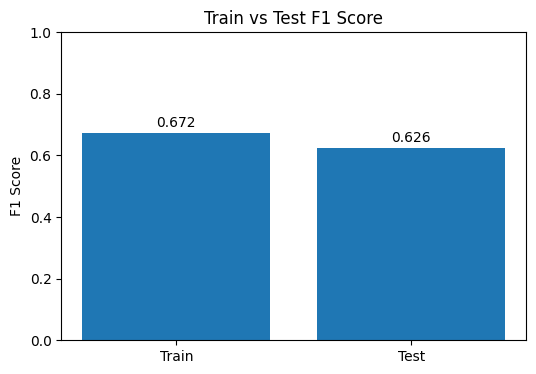

In [13]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# Predictions
train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

# Metrics
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

# Plot
plt.figure(figsize=(6,4))
plt.bar(['Train', 'Test'], [train_f1, test_f1])

plt.ylabel('F1 Score')
plt.title('Train vs Test F1 Score')
plt.ylim(0, 1)

for i, v in enumerate([train_f1, test_f1]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.show()

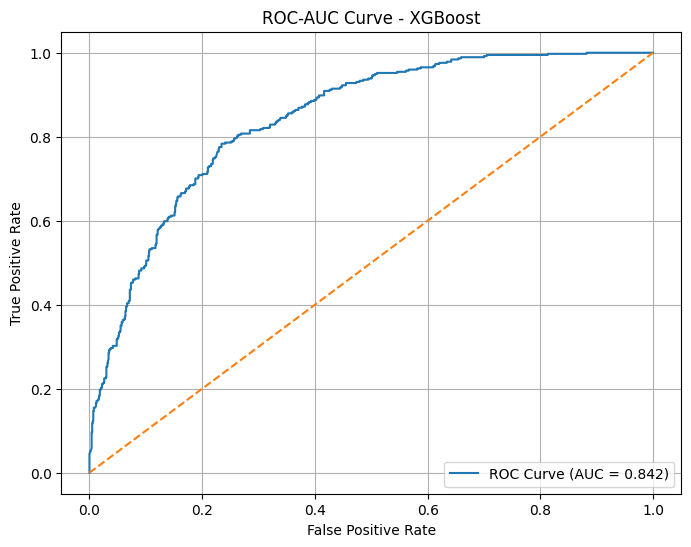

ROC-AUC Score: 0.842


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities for positive class
y_proba = xgb.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print(f"ROC-AUC Score: {auc_score:.3f}")

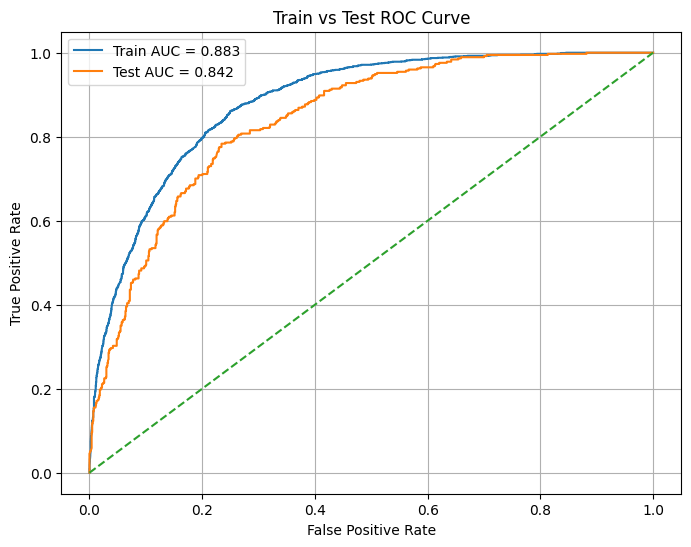

Train AUC: 0.8827452282426489
Test AUC : 0.8420673910680174


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Train
train_proba = xgb.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_proba)
fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)

# Test
test_proba = xgb.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(8,6))

plt.plot(fpr_train, tpr_train,
         label=f'Train AUC = {train_auc:.3f}')

plt.plot(fpr_test, tpr_test,
         label=f'Test AUC = {test_auc:.3f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Train AUC:", train_auc)
print("Test AUC :", test_auc)

## MLflow

In [15]:
# import mlflow
# import mlflow.sklearn
# from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
# import time
# import os

# # Force MLflow to always use the project root's mlruns folder
# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
# mlflow.set_experiment("Telco Churn - XGBoost")

# with mlflow.start_run():
#     # Calculate scale_pos_weight
#     scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#     # Best params from Optuna
#     best_params = study.best_params
#     best_params.update({
#         "random_state": 42,
#         "n_jobs": -1,
#         "scale_pos_weight": scale_pos_weight,
#         "eval_metric": "logloss"
#     })

#     # Log parameters
#     mlflow.log_params(best_params)

#     # Training timer
#     start_train = time.time()
#     xgb = XGBClassifier(**best_params)
#     xgb.fit(X_train, y_train)
#     train_time = time.time() - start_train
#     mlflow.log_metric("train_time", train_time)

#     # Prediction
#     start_pred = time.time()
#     proba = xgb.predict_proba(X_test)[:, 1]
#     y_pred = (proba >= THRESHOLD).astype(int)
#     pred_time = time.time() - start_pred
#     mlflow.log_metric("pred_time", pred_time)

#     # Metrics
#     precision = precision_score(y_test, y_pred, pos_label=1)
#     recall = recall_score(y_test, y_pred, pos_label=1)
#     f1 = f1_score(y_test, y_pred, pos_label=1)
#     auc = roc_auc_score(y_test, proba)

#     mlflow.log_metric("precision", precision)
#     mlflow.log_metric("recall", recall)
#     mlflow.log_metric("f1", f1)
#     mlflow.log_metric("roc_auc", auc)

#     # Save model
#     mlflow.xgboost.log_model(xgb, "model")

#     print(classification_report(y_test, y_pred, digits=3))